# Demo 3 — Self-Attention: O Coração do Transformer

## O que vamos fazer aqui?

Vamos construir e visualizar o mecanismo de **self-attention** do zero, usando apenas **numpy** e **matplotlib**.

Nenhum PyTorch, nenhum TensorFlow, nenhuma biblioteca de deep learning.

---

## O que é Atenção?

Imagine que você está lendo a frase:

> *"a produtividade caiu porque a estiagem afetou a lavoura"*

Quando você chega na palavra **"caiu"**, seu cérebro imediatamente conecta essa palavra a **"estiagem"** e **"produtividade"**. Você não lê as palavras de forma isolada — você atribui relevâncias diferentes a cada parte do contexto.

**Isso é exatamente o que o mecanismo de atenção faz:**

> *"cada token pode olhar para todos os outros e atribuir relevância diferente"*

---

## Por que isso resolve o problema do contexto longo? (link com Demo 2)

Na **Demo 2**, vimos que RNNs e LSTMs sofrem com contexto longo:
- A informação precisa viajar **passo a passo** pela cadeia de tokens
- Em frases longas, os primeiros tokens são "esquecidos" pelos últimos
- A memória da LSTM é uma **gaveta apertada**: guarda pouca coisa ao mesmo tempo

O mecanismo de atenção resolve isso de forma elegante:
- Não há processamento sequencial — **todos os tokens falam com todos ao mesmo tempo**
- A distância entre dois tokens na frase não importa — o custo de conexão é o mesmo
- Em vez de "memória acumulada", temos uma **matriz de relações** completa

---

## O que vamos construir

| Parte | Conteúdo |
|-------|----------|
| 1 | Introdução (esta célula) |
| 2 | Corpus e vocabulário |
| 3 | Embeddings por co-ocorrência |
| 4 | A fórmula da atenção |
| 5 | Implementação em NumPy |
| 6 | Visualização 1: Tabela de atenção |
| 7 | Visualização 2: Heatmap |
| 8 | Visualização 3: Texto com pesos |
| 9 | Comparando frases diferentes |
| 10 | Atenção multi-cabeça (conceitual) |
| 11 | Resumo comparativo |

---

> **Frase para guardar:**  
> *"O transformer não usa memória sequencial — ele computa diretamente o quanto cada token é relevante para cada outro token."*

---
## Parte 1 — Importações

Vamos usar apenas **numpy** (álgebra linear) e **matplotlib** (visualizações).

Sem PyTorch, sem TensorFlow, sem sklearn.


In [1]:
# numpy: toda a álgebra linear (matrizes, multiplicações, softmax, etc.)
import numpy as np

# matplotlib.pyplot: para gerar os heatmaps e visualizações
import matplotlib.pyplot as plt

# matplotlib.colors: para trabalhar com colormaps customizados
import matplotlib.colors as mcolors

# re: expressões regulares para limpar pontuação na tokenização
import re

# Seed fixo para garantir reprodutibilidade em todo o notebook
# (usado nas projeções aleatórias da atenção multi-cabeça)
np.random.seed(42)

print("Dependências carregadas com sucesso.")
print(f"NumPy versão: {np.__version__}")
print("Nenhuma dependência de deep learning necessária.")

Dependências carregadas com sucesso.
NumPy versão: 2.4.1
Nenhuma dependência de deep learning necessária.


---
## Parte 2 — Corpus e Vocabulário

Usamos o mesmo corpus do agro brasileiro das demos anteriores.

A tokenização também é a mesma:
1. Converter para minúsculas ("Milho" = "milho")
2. Remover pontuação ("lavoura," = "lavoura")
3. Dividir por espaço
4. Filtrar strings vazias

O vocabulário é o conjunto de **todos os tokens únicos** que aparecem no corpus.

Cada token recebe um **índice inteiro** — esse índice vai ser usado para indexar as linhas e colunas das nossas matrizes.


In [2]:
# =========================================================
# CORPUS — mesmo conjunto de frases das demos anteriores
# =========================================================
corpus = [
    "a produtividade caiu porque a estiagem afetou a lavoura",
    "a produtividade subiu porque a chuva beneficiou a lavoura",
    "a lavoura de milho sofreu com a estiagem por isso a produtividade caiu",
    "a lavoura de soja melhorou com a chuva por isso a produtividade subiu",
    "o produtor investiu em irrigacao e a produtividade aumentou bastante",
    "o solo seco prejudicou a lavoura e a produtividade do milho caiu",
    "a chuva regular garantiu boa produtividade ao produtor rural",
    "a estiagem prolongada destruiu a lavoura de cafe e milho",
]

def tokenizar(frase):
    """
    Transforma uma frase em lista de tokens.

    Passos:
    1. lower(): minúsculas — 'Milho' e 'milho' viram o mesmo token
    2. re.sub: remove tudo que não for letra, número ou espaço
    3. split(): divide nos espaços
    4. filtro: descarta strings vazias (espaços duplos, etc.)
    """
    frase = frase.lower()                          # minúsculas
    frase = re.sub(r'[^a-záéíóúãõâêôàüç\s]', '', frase)  # remove pontuação
    tokens = [t for t in frase.split() if t]       # split e filtra vazios
    return tokens

# Tokenizamos todas as frases do corpus
corpus_tokenizado = [tokenizar(frase) for frase in corpus]

# =========================================================
# VOCABULÁRIO — conjunto de tokens únicos, ordenados
# =========================================================

# Achata a lista de listas em uma única lista de todos os tokens
todos_tokens = [token for frase in corpus_tokenizado for token in frase]

# sorted() garante ordem determinística — importante para reprodutibilidade
vocabulario = sorted(set(todos_tokens))

# Mapeamento palavra → índice (usado para indexar matrizes)
palavra_para_idx = {palavra: i for i, palavra in enumerate(vocabulario)}

# Mapeamento índice → palavra (usado para exibir resultados)
idx_para_palavra = {i: palavra for palavra, i in palavra_para_idx.items()}

V = len(vocabulario)  # tamanho do vocabulário

print(f"Total de frases no corpus: {len(corpus)}")
print(f"Total de tokens (com repetição): {len(todos_tokens)}")
print(f"Tamanho do vocabulário (tokens únicos): {V}")
print()
print("Vocabulário completo:")
print(vocabulario)
print()
print("Exemplo de tokenização:")
print(f"  '{corpus[0]}'")
print(f"  → {corpus_tokenizado[0]}")

Total de frases no corpus: 8
Total de tokens (com repetição): 85
Tamanho do vocabulário (tokens únicos): 38

Vocabulário completo:
['a', 'afetou', 'ao', 'aumentou', 'bastante', 'beneficiou', 'boa', 'cafe', 'caiu', 'chuva', 'com', 'de', 'destruiu', 'do', 'e', 'em', 'estiagem', 'garantiu', 'investiu', 'irrigacao', 'isso', 'lavoura', 'melhorou', 'milho', 'o', 'por', 'porque', 'prejudicou', 'produtividade', 'produtor', 'prolongada', 'regular', 'rural', 'seco', 'sofreu', 'soja', 'solo', 'subiu']

Exemplo de tokenização:
  'a produtividade caiu porque a estiagem afetou a lavoura'
  → ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']


---
## Parte 3 — Embeddings por Co-ocorrência

### O que é um embedding?

Um **embedding** é uma representação numérica de uma palavra — um vetor de números reais.

A ideia fundamental, que vem da linguística distribucional (Harris, 1954):

> *"Você pode conhecer uma palavra pela companhia que ela mantém."*

Palavras que aparecem nos mesmos contextos têm significados semelhantes. Então podemos representar uma palavra pelo seu **padrão de co-ocorrência** com outras palavras.

### Como construímos a matriz de co-ocorrência?

Para cada token no corpus, olhamos para os `janela` tokens vizinhos (aqui usamos janela = 2).

Para a frase `"a produtividade caiu porque"`, com janela = 2:
- "produtividade" co-ocorre com: "a", "caiu", "porque" (2 à esquerda, 2 à direita)
- "caiu" co-ocorre com: "a", "produtividade", "porque"

Cada linha da matriz de co-ocorrência é o **vetor de contexto** de uma palavra.

### Por que normalizar?

Depois de construir a matriz, normalizamos cada linha para ter norma 1 (vetor unitário).

Isso garante que a similaridade entre palavras seja medida por **direção**, não por frequência absoluta.

Palavras que aparecem nos mesmos contextos terão vetores **apontando na mesma direção** — ou seja, produto interno próximo de 1.


In [3]:
# =========================================================
# MATRIZ DE CO-OCORRÊNCIA
# =========================================================

JANELA = 2  # quantos vizinhos olhamos para cada lado

# Inicializa a matriz com zeros
# Dimensão: (V x V) — para cada par (palavra_i, palavra_j), quantas vezes co-ocorreram
cooc = np.zeros((V, V), dtype=np.float64)

for frase_tokens in corpus_tokenizado:
    n = len(frase_tokens)
    for pos, token in enumerate(frase_tokens):
        idx_centro = palavra_para_idx[token]

        # Define os limites da janela de contexto
        inicio = max(0, pos - JANELA)      # não vai além do início da frase
        fim    = min(n, pos + JANELA + 1)  # não vai além do fim da frase

        for pos_viz in range(inicio, fim):
            if pos_viz == pos:
                continue  # não conta a própria palavra como vizinha
            idx_viz = palavra_para_idx[frase_tokens[pos_viz]]
            cooc[idx_centro, idx_viz] += 1  # incrementa a contagem de co-ocorrência

# =========================================================
# NORMALIZAÇÃO — transforma cada linha em vetor unitário
# =========================================================

# Calcula a norma (comprimento) de cada linha
# keepdims=True mantém as dimensões para o broadcast funcionar
normas = np.linalg.norm(cooc, axis=1, keepdims=True)

# Evita divisão por zero: palavras sem co-ocorrência ficam com vetor zero
normas[normas == 0] = 1

# Os embeddings são os vetores normalizados
# Dimensão final: (V, V) — cada palavra é representada por um vetor de tamanho V
embeddings = cooc / normas

print(f"Matriz de co-ocorrência: {cooc.shape}")
print(f"Embeddings normalizados: {embeddings.shape}")
print(f"Cada palavra tem um vetor de dimensão {embeddings.shape[1]}")
print()

# Verifica que as linhas são de fato unitárias (norma ≈ 1)
normas_check = np.linalg.norm(embeddings, axis=1)
# Algumas palavras podem ter norma 0 se não tiveram vizinhos — filtramos
normas_nao_zero = normas_check[normas_check > 0]
print(f"Norma média dos embeddings (deve ser 1.0): {normas_nao_zero.mean():.6f}")

# Mostra a similaridade entre palavras temáticas
print()
print("Similaridade por produto interno (palavras normalizadas):")
pares = [("estiagem", "caiu"), ("chuva", "subiu"), ("estiagem", "chuva"), ("lavoura", "produtividade")]
for w1, w2 in pares:
    v1 = embeddings[palavra_para_idx[w1]]
    v2 = embeddings[palavra_para_idx[w2]]
    sim = np.dot(v1, v2)  # produto interno de vetores unitários = cosseno do ângulo
    print(f"  sim('{w1}', '{w2}') = {sim:.4f}")

Matriz de co-ocorrência: (38, 38)
Embeddings normalizados: (38, 38)
Cada palavra tem um vetor de dimensão 38

Norma média dos embeddings (deve ser 1.0): 1.000000

Similaridade por produto interno (palavras normalizadas):
  sim('estiagem', 'caiu') = 0.6777
  sim('chuva', 'subiu') = 0.7245
  sim('estiagem', 'chuva') = 0.8696
  sim('lavoura', 'produtividade') = 0.6924


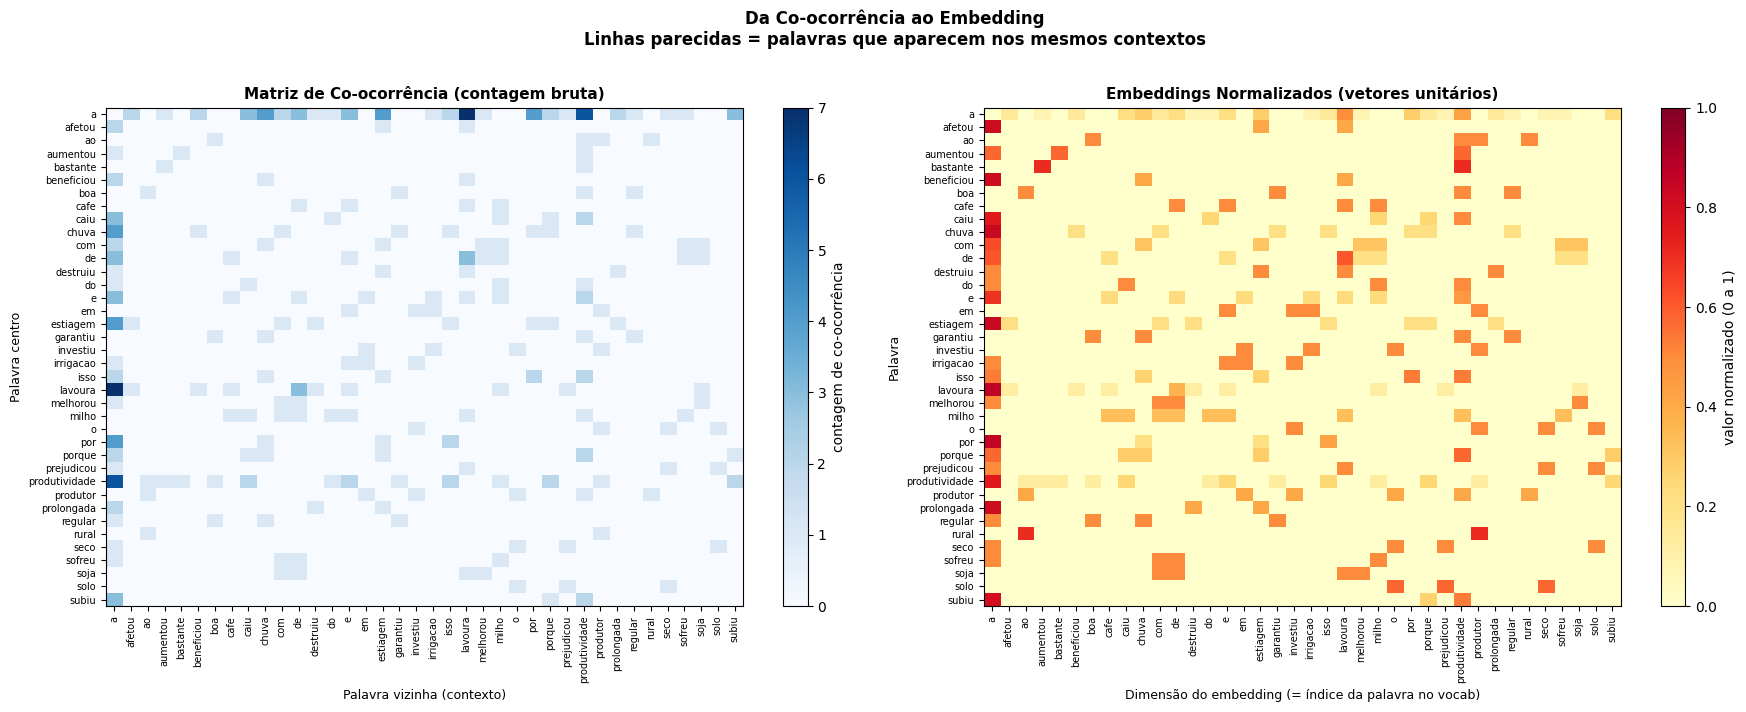


Leitura do heatmap:
  - Cada LINHA é um embedding (vetor de uma palavra)
  - Linhas visualmente parecidas = palavras com contextos parecidos
  - 'estiagem' e 'chuva' devem ter linhas com padrão similar (ambas afetam lavoura)
  - 'caiu' e 'subiu' também têm padrões similares (ambas são consequências)


In [4]:
# =========================================================
# HEATMAP DA MATRIZ DE CO-OCORRÊNCIA
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Painel esquerdo: contagens brutas de co-ocorrência ---
ax1 = axes[0]
im1 = ax1.imshow(cooc, cmap='Blues', aspect='auto')
plt.colorbar(im1, ax=ax1, label='contagem de co-ocorrência')
ax1.set_xticks(range(V))
ax1.set_yticks(range(V))
ax1.set_xticklabels(vocabulario, rotation=90, fontsize=7)
ax1.set_yticklabels(vocabulario, fontsize=7)
ax1.set_title('Matriz de Co-ocorrência (contagem bruta)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Palavra vizinha (contexto)', fontsize=9)
ax1.set_ylabel('Palavra centro', fontsize=9)

# --- Painel direito: embeddings normalizados ---
ax2 = axes[1]
im2 = ax2.imshow(embeddings, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax2, label='valor normalizado (0 a 1)')
ax2.set_xticks(range(V))
ax2.set_yticks(range(V))
ax2.set_xticklabels(vocabulario, rotation=90, fontsize=7)
ax2.set_yticklabels(vocabulario, fontsize=7)
ax2.set_title('Embeddings Normalizados (vetores unitários)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Dimensão do embedding (= índice da palavra no vocab)', fontsize=9)
ax2.set_ylabel('Palavra', fontsize=9)

plt.suptitle(
    'Da Co-ocorrência ao Embedding\n'
    'Linhas parecidas = palavras que aparecem nos mesmos contextos',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

print()
print("Leitura do heatmap:")
print("  - Cada LINHA é um embedding (vetor de uma palavra)")
print("  - Linhas visualmente parecidas = palavras com contextos parecidos")
print("  - 'estiagem' e 'chuva' devem ter linhas com padrão similar (ambas afetam lavoura)")
print("  - 'caiu' e 'subiu' também têm padrões similares (ambas são consequências)")

---
## Parte 4 — A Fórmula da Atenção

### A analogia: Consulta, Chave, Valor

O mecanismo de atenção usa três conceitos que vêm de sistemas de busca de informação:

| Símbolo | Nome | Analogia com busca |
|---------|------|--------------------|
| **Q** | Query (Consulta) | O que estou procurando? |
| **K** | Key (Chave) | O que cada item oferece? |
| **V** | Value (Valor) | O que cada item realmente contém? |

**Exemplo intuitivo:** Imagine um banco de dados de artigos agrícolas.
- Sua **query** é: *"estiagem em cerrado"*
- Cada artigo tem uma **key**: *"clima seco", "irrigação", "soja no cerrado"*, etc.
- Você compara sua query com todas as keys e calcula uma relevância (score)
- O resultado final é uma **média ponderada** dos **values** (conteúdos), onde o peso é a relevância

No self-attention, **cada token é ao mesmo tempo query, key e value** — cada palavra pergunta e responde.

---

### A Fórmula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^{\top}}{\sqrt{d_k}}\right) \cdot V$$

Onde:
- $Q \in \mathbb{R}^{T \times d_k}$ — matriz de queries (T tokens, cada um com dimensão $d_k$)
- $K \in \mathbb{R}^{T \times d_k}$ — matriz de keys
- $V \in \mathbb{R}^{T \times d_v}$ — matriz de values
- $QK^{\top} \in \mathbb{R}^{T \times T}$ — matriz de scores (quanto cada query "combina" com cada key)
- $\sqrt{d_k}$ — fator de escala
- $\text{softmax}(\cdot) \cdot V$ — média ponderada dos values

---

### Por que o $\sqrt{d_k}$?

Sem o fator de escala, os produtos internos $QK^{\top}$ crescem proporcionalmente a $d_k$.

Com vetores de alta dimensão (ex: $d_k = 512$), os scores ficam muito grandes, e a softmax vira uma função quase binária (um score domina tudo, os outros vão a zero).

Dividir por $\sqrt{d_k}$ mantém os scores em uma escala razoável — a softmax continua "suave" e distribui atenção de forma mais equilibrada.

---

### Versão simplificada (que usaremos aqui)

No transformer real, Q, K, V são **projeções lineares** diferentes do embedding de entrada:
$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

Para desmistificar o mecanismo, vamos usar a versão simplificada onde:
$$Q = K = V = X \quad \text{(os próprios embeddings)}$$

Isso é matematicamente válido e mostra a essência do mecanismo sem a complexidade das projeções.

---
## Parte 5 — Implementação em NumPy

Agora vamos implementar a fórmula passo a passo.

Precisamos de duas funções auxiliares:
1. `softmax`: normaliza um vetor de scores para que somem 1 (distribuição de probabilidade)
2. `self_attention`: recebe a matriz de embeddings da frase e retorna a matriz de atenção

A entrada da função `self_attention` é uma **matriz X de shape (T, d)**:
- T = número de tokens na frase
- d = dimensão do embedding de cada token

A saída são dois objetos:
- `pesos`: matriz de atenção (T, T) — quanto cada token atende a cada outro
- `saida`: representação contextualizada (T, d) — cada token enriquecido pelo contexto


In [5]:
# =========================================================
# FUNÇÃO AUXILIAR: softmax numericamente estável
# =========================================================

def softmax(x):
    """
    Calcula o softmax de um vetor ou de cada linha de uma matriz.

    softmax(x_i) = exp(x_i) / sum(exp(x_j))

    Truque numérico: subtraímos o máximo antes de calcular exp().
    Isso evita overflow (exp de número muito grande = infinito)
    sem mudar o resultado matemático (a constante cancela na divisão).

    Args:
        x: array 1D (vetor) ou 2D (linhas serão normalizadas independentemente)

    Returns:
        array de mesma shape com valores entre 0 e 1, somando 1 por linha
    """
    if x.ndim == 1:
        # Caso 1D: vetor simples
        x_estavel = x - np.max(x)           # subtrai o máximo (truque de estabilidade)
        e = np.exp(x_estavel)               # exponencial de cada elemento
        return e / e.sum()                  # normaliza para somar 1
    else:
        # Caso 2D: cada linha é normalizada independentemente
        x_estavel = x - x.max(axis=1, keepdims=True)  # subtrai o max de cada linha
        e = np.exp(x_estavel)                          # exp elemento a elemento
        return e / e.sum(axis=1, keepdims=True)        # divide pela soma da linha


# =========================================================
# FUNÇÃO PRINCIPAL: self-attention
# =========================================================

def self_attention(X, d_k=None):
    """
    Calcula o self-attention de uma sequência de embeddings.

    Implementa: Attention(Q,K,V) = softmax(QKᵀ / sqrt(d_k)) · V
    Na versão simplificada: Q = K = V = X

    Args:
        X:   array de shape (T, d)
                T = número de tokens na frase
                d = dimensão do embedding de cada token
        d_k: dimensão usada para o fator de escala.
                Se None, usa d (dimensão total do embedding).

    Returns:
        pesos:  array (T, T) — matriz de pesos de atenção
                  pesos[i, j] = quanto o token i atende ao token j
                  cada linha soma 1 (é uma distribuição de probabilidade)
        saida:  array (T, d) — representação contextualizada
                  cada linha i é a média ponderada das linhas de X
                  usando os pesos da linha i
    """
    T, d = X.shape                   # T tokens, cada um com d dimensões

    if d_k is None:
        d_k = d                      # usa a dimensão total do embedding

    # --- PASSO 1: Calcular scores brutos ---
    # Q = K = X (versão simplificada — sem projeções separadas)
    # scores[i, j] = produto interno entre embedding[i] e embedding[j]
    # Mede o quanto o token i é "compatível" com o token j
    # Shape: (T, T)
    scores = X @ X.T                 # @ é multiplicação matricial em numpy

    # --- PASSO 2: Escalar os scores ---
    # Divide por sqrt(d_k) para evitar que os scores explodam em alta dimensão
    # Sem isso, a softmax ficaria saturada (quase 0/1 binário)
    escala = np.sqrt(d_k)
    scores_escalados = scores / escala

    # --- PASSO 3: Softmax — transforma scores em pesos de atenção ---
    # Cada linha i vira uma distribuição de probabilidade:
    #   pesos[i, j] = o quanto o token i 'presta atenção' ao token j
    # Shape continua (T, T), mas agora cada linha soma 1
    pesos = softmax(scores_escalados)

    # --- PASSO 4: Média ponderada dos values ---
    # V = X (versão simplificada)
    # saida[i] = soma ponderada de todos os embeddings, com pesos pesos[i, :]
    # Ou seja: o token i 'coleta' informação de todos os outros tokens
    # Shape: (T, d)
    saida = pesos @ X

    return pesos, saida


# =========================================================
# FUNÇÃO AUXILIAR: busca o embedding de uma frase
# =========================================================

def embedding_da_frase(tokens):
    """
    Dado uma lista de tokens, retorna a matriz de embeddings da frase.

    Args:
        tokens: lista de strings (tokens da frase)

    Returns:
        X: array (T, V) onde T = len(tokens), V = tamanho do vocabulário
        tokens_validos: tokens que existem no vocabulário
    """
    # Filtra tokens que não estão no vocabulário
    tokens_validos = [t for t in tokens if t in palavra_para_idx]

    # Para cada token, busca o vetor de embedding na linha correspondente da matriz
    X = np.array([embeddings[palavra_para_idx[t]] for t in tokens_validos])

    return X, tokens_validos


print("Funções implementadas com sucesso.")
print()

# Teste rápido com a primeira frase do corpus
frase_teste = corpus[0]
tokens_teste = tokenizar(frase_teste)
X_teste, tokens_validos = embedding_da_frase(tokens_teste)
pesos_teste, saida_teste = self_attention(X_teste)

print(f"Frase: '{frase_teste}'")
print(f"Tokens: {tokens_validos}")
print(f"Shape da matriz de entrada X: {X_teste.shape}  (T tokens × d dimensões)")
print(f"Shape dos pesos de atenção:   {pesos_teste.shape}  (T × T)")
print(f"Shape da saída contextualizada: {saida_teste.shape}  (T × d)")
print()
print("Verificação: cada linha dos pesos deve somar 1 (distribuição de prob.):")
for i, token in enumerate(tokens_validos):
    soma = pesos_teste[i].sum()
    print(f"  Token '{token}': soma dos pesos = {soma:.6f}")

Funções implementadas com sucesso.

Frase: 'a produtividade caiu porque a estiagem afetou a lavoura'
Tokens: ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']
Shape da matriz de entrada X: (9, 38)  (T tokens × d dimensões)
Shape dos pesos de atenção:   (9, 9)  (T × T)
Shape da saída contextualizada: (9, 38)  (T × d)

Verificação: cada linha dos pesos deve somar 1 (distribuição de prob.):
  Token 'a': soma dos pesos = 1.000000
  Token 'produtividade': soma dos pesos = 1.000000
  Token 'caiu': soma dos pesos = 1.000000
  Token 'porque': soma dos pesos = 1.000000
  Token 'a': soma dos pesos = 1.000000
  Token 'estiagem': soma dos pesos = 1.000000
  Token 'afetou': soma dos pesos = 1.000000
  Token 'a': soma dos pesos = 1.000000
  Token 'lavoura': soma dos pesos = 1.000000


---
## Parte 6 — Visualização 1: Tabela de Atenção

Antes de plotar qualquer gráfico, é útil ver a matriz de atenção **como tabela de texto**.

Isso nos permite:
- Verificar os valores exatos
- Entender o que cada célula significa
- Identificar visualmente quais pesos são maiores

**Leitura da tabela:**
- Cada **linha** representa um token que está fazendo a "pergunta" (query)
- Cada **coluna** representa um token que está sendo "consultado" (key)
- O valor na célula (linha i, coluna j) = quanto o token i presta atenção ao token j
- Cada linha soma 1.0 (é uma distribuição de probabilidade)

Vamos destacar os valores mais altos de cada linha com `[**]`.


In [6]:
# =========================================================
# TABELA DE ATENÇÃO — frase 1: "a produtividade caiu porque a estiagem afetou a lavoura"
# =========================================================

frase_analise = corpus[0]  # "a produtividade caiu porque a estiagem afetou a lavoura"
tokens_analise = tokenizar(frase_analise)

# Obtém os embeddings e calcula a atenção
X_analise, tokens_analise_validos = embedding_da_frase(tokens_analise)
pesos_analise, _ = self_attention(X_analise)

T = len(tokens_analise_validos)  # número de tokens na frase

print(f"Frase analisada: '{frase_analise}'")
print(f"Tokens: {tokens_analise_validos}")
print()
print("=" * 90)
print("MATRIZ DE ATENÇÃO — linha = query (quem pergunta), coluna = key (quem responde)")
print("Valores entre 0 e 1. Cada linha soma 1.0.")
print("[**] = maior valor da linha  |  [* ] = segundo maior")
print("=" * 90)

# Calcula o comprimento máximo dos tokens para alinhar as colunas
max_len_token = max(len(t) for t in tokens_analise_validos)
col_width = max(max_len_token, 5) + 2  # largura de cada coluna

# Cabeçalho da tabela
header_query = "Query \\ Key".ljust(max_len_token + 2)
header_cols  = "".join(t.center(col_width) for t in tokens_analise_validos)
print(f"{header_query}  {header_cols}")
print("-" * (max_len_token + 2 + 2 + T * col_width))

# Linha a linha da matriz
for i, token_query in enumerate(tokens_analise_validos):
    linha = pesos_analise[i]  # vetor de pesos para este query

    # Encontra os índices dos top-2 valores
    top2 = np.argsort(linha)[-2:]  # dois maiores índices
    idx_max  = top2[-1]            # o maior
    idx_seg  = top2[-2]            # o segundo maior

    # Formata o nome do token query (alinhado à esquerda)
    label_query = token_query.ljust(max_len_token + 2)

    # Formata cada valor da linha
    celulas = []
    for j, val in enumerate(linha):
        if j == idx_max:
            celula = f"[**{val:.3f}]"  # destaque para o maior
        elif j == idx_seg:
            celula = f"[* {val:.3f}]"  # destaque para o segundo
        else:
            celula = f"  {val:.3f} "   # valor normal
        celulas.append(celula.center(col_width))

    print(f"{label_query}  {''.join(celulas)}")

print("-" * (max_len_token + 2 + 2 + T * col_width))
print()

# Sumário: para cada token, mostra o token que recebe mais atenção dele
print("Sumário — o token mais atendido por cada query:")
for i, token_query in enumerate(tokens_analise_validos):
    idx_max = np.argmax(pesos_analise[i])
    token_max = tokens_analise_validos[idx_max]
    peso_max  = pesos_analise[i, idx_max]
    print(f"  '{token_query}'  →  '{token_max}'  (peso = {peso_max:.4f})")

Frase analisada: 'a produtividade caiu porque a estiagem afetou a lavoura'
Tokens: ['a', 'produtividade', 'caiu', 'porque', 'a', 'estiagem', 'afetou', 'a', 'lavoura']

MATRIZ DE ATENÇÃO — linha = query (quem pergunta), coluna = key (quem responde)
Valores entre 0 e 1. Cada linha soma 1.0.
[**] = maior valor da linha  |  [* ] = segundo maior
Query \ Key             a        produtividade       caiu          porque           a           estiagem        afetou           a           lavoura    
--------------------------------------------------------------------------------------------------------------------------------------------------------
a                   [* 0.120]         0.106          0.106          0.111          0.120          0.106          0.107       [**0.120]         0.104    
produtividade          0.106       [**0.119]         0.113          0.111          0.106       [* 0.114]         0.112          0.106          0.113    
caiu                   0.106          0.113  

---
## Parte 7 — Visualização 2: Heatmap da Matriz de Atenção

A tabela de texto é boa para inspecionar valores individuais, mas o **heatmap** revela o padrão global de uma vez só.

- Cores quentes (vermelho/laranja) = atenção alta
- Cores frias (amarelo claro/branco) = atenção baixa
- A diagonal principal tende a ter valores altos — cada token naturalmente presta atenção a si mesmo

Procure por padrões fora da diagonal: eles indicam relações semânticas importantes entre tokens.


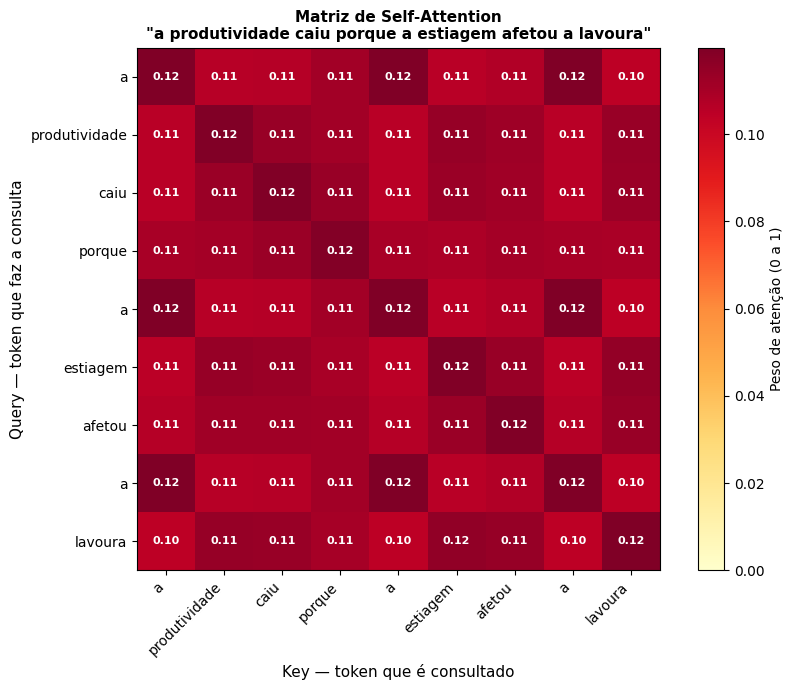


O que observar no heatmap:
  - Diagonal: cada token atende a si mesmo (esperado)
  - 'caiu' atende a: 'caiu' (0.119)  'porque' (0.114)  'produtividade' (0.113)  


In [7]:
# =========================================================
# HEATMAP DA MATRIZ DE ATENÇÃO
# =========================================================

fig, ax = plt.subplots(figsize=(9, 7))

# Plota a matriz de pesos como imagem colorida
# pcolor='YlOrRd': amarelo (baixo) → laranja → vermelho (alto)
im = ax.imshow(pesos_analise, cmap='YlOrRd', vmin=0, vmax=pesos_analise.max())

# Barra de cores lateral com legenda
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Peso de atenção (0 a 1)', fontsize=10)

# Define os ticks e labels dos eixos
ax.set_xticks(range(T))
ax.set_yticks(range(T))
# Eixo X = keys (quem responde) — labels rotacionados para não sobrepor
ax.set_xticklabels(tokens_analise_validos, rotation=45, ha='right', fontsize=10)
# Eixo Y = queries (quem pergunta)
ax.set_yticklabels(tokens_analise_validos, fontsize=10)

# Labels dos eixos
ax.set_xlabel('Key — token que é consultado', fontsize=11)
ax.set_ylabel('Query — token que faz a consulta', fontsize=11)

# Título explicativo
ax.set_title(
    f'Matriz de Self-Attention\n"{frase_analise}"',
    fontsize=11, fontweight='bold'
)

# Anota os valores numéricos dentro de cada célula do heatmap
for i in range(T):
    for j in range(T):
        val = pesos_analise[i, j]
        # Escolhe cor do texto baseado no valor (claro sobre fundo escuro, escuro sobre fundo claro)
        cor_texto = 'white' if val > pesos_analise.max() * 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=cor_texto, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("O que observar no heatmap:")
print("  - Diagonal: cada token atende a si mesmo (esperado)")
print("  - 'caiu' atende a: ", end="")
idx_caiu = tokens_analise_validos.index('caiu') if 'caiu' in tokens_analise_validos else None
if idx_caiu is not None:
    top3_caiu = np.argsort(pesos_analise[idx_caiu])[-3:][::-1]
    for idx in top3_caiu:
        print(f"'{tokens_analise_validos[idx]}' ({pesos_analise[idx_caiu, idx]:.3f})", end="  ")
    print()

---
## Parte 8 — Visualização 3: Texto com Pesos de Atenção

Os heatmaps são poderosos, mas às vezes queremos ver a atenção **diretamente na frase**.

Vamos fazer duas sub-visualizações:

### 8a — Top-3 tokens mais atendidos (barras ASCII)

Para cada token da frase, mostramos os 3 tokens que ele mais atende, com barras proporcionais ao peso.

### 8b — Frase com intensidade de atenção (blocos Unicode)

Para um token foco, mostramos a frase inteira com cada palavra marcada por um bloco Unicode proporcional ao peso de atenção:

| Caractere | Intensidade |
|-----------|-------------|
| `░` | muito baixa (0 – 25%) |
| `▒` | baixa-média (25 – 50%) |
| `▓` | média-alta (50 – 75%) |
| `█` | alta (75 – 100%) |


In [8]:
# =========================================================
# VISUALIZAÇÃO 8a — Top-3 por token com barras ASCII
# =========================================================

def barra_ascii(valor, maximo, largura=20):
    """
    Gera uma barra ASCII proporcional ao valor.

    Args:
        valor:   o valor a representar
        maximo:  o valor máximo (define 100% da barra)
        largura: número máximo de blocos na barra

    Returns:
        string com blocos █ proporcional ao valor
    """
    if maximo == 0:
        return ""
    n_blocos = int(round((valor / maximo) * largura))  # quantos blocos acender
    return '█' * n_blocos


print("=" * 60)
print("VISUALIZAÇÃO 8a — Top-3 tokens mais atendidos por cada query")
print(f"Frase: '{frase_analise}'")
print("=" * 60)

# Largura máxima dos tokens para alinhar as barras
max_tok_len = max(len(t) for t in tokens_analise_validos)

# Valor máximo global — usado para normalizar as barras de forma comparável
peso_maximo_global = pesos_analise.max()

for i, token_query in enumerate(tokens_analise_validos):
    linha = pesos_analise[i]  # pesos deste query para todos os keys

    # Pega os índices dos top-3 pesos (do maior para o menor)
    top3_idx = np.argsort(linha)[-3:][::-1]

    print(f"\n  '{token_query}' atende mais a:")
    for j in top3_idx:
        token_key = tokens_analise_validos[j]
        peso      = linha[j]
        barra     = barra_ascii(peso, peso_maximo_global, largura=16)
        # Formata: nome do token (alinhado), barra, valor numérico
        print(f"    {token_key.ljust(max_tok_len)}  {barra.ljust(16)}  {peso:.4f}")

print()

VISUALIZAÇÃO 8a — Top-3 tokens mais atendidos por cada query
Frase: 'a produtividade caiu porque a estiagem afetou a lavoura'

  'a' atende mais a:
    a              ████████████████  0.1198
    a              ████████████████  0.1198
    a              ████████████████  0.1198

  'produtividade' atende mais a:
    produtividade  ████████████████  0.1192
    estiagem       ███████████████   0.1141
    lavoura        ███████████████   0.1134

  'caiu' atende mais a:
    caiu           ████████████████  0.1190
    porque         ███████████████   0.1137
    produtividade  ███████████████   0.1131

  'porque' atende mais a:
    porque         ████████████████  0.1184
    caiu           ███████████████   0.1132
    afetou         ███████████████   0.1108

  'a' atende mais a:
    a              ████████████████  0.1198
    a              ████████████████  0.1198
    a              ████████████████  0.1198

  'estiagem' atende mais a:
    estiagem       ████████████████  0.1193
    lavoura

In [9]:
# =========================================================
# VISUALIZAÇÃO 8b — Frase com blocos Unicode de intensidade
# =========================================================

# Blocos Unicode ordenados por intensidade crescente
BLOCOS = ['░', '▒', '▓', '█']

def bloco_unicode(peso, peso_min, peso_max):
    """
    Mapeia um peso de atenção para um bloco Unicode de intensidade.

    Divide o intervalo [peso_min, peso_max] em 4 faixas iguais.
    Retorna blocos repetidos proporcionais ao peso.

    Args:
        peso:     valor a mapear
        peso_min: valor mínimo da escala
        peso_max: valor máximo da escala

    Returns:
        string com blocos Unicode representando a intensidade
    """
    if peso_max == peso_min:
        return BLOCOS[0]  # caso degenerado: todos os pesos iguais

    # Normaliza para [0, 1]
    norm = (peso - peso_min) / (peso_max - peso_min)

    # Índice do bloco: 0, 1, 2, ou 3
    idx = min(int(norm * len(BLOCOS)), len(BLOCOS) - 1)

    # Número de blocos: de 1 (mínimo) a 4 (máximo)
    n_blocos = idx + 1

    return BLOCOS[idx] * n_blocos  # ex: '▓▓▓' para intensidade média-alta


# Tokens foco para visualização
tokens_foco = ['caiu', 'produtividade', 'estiagem']
tokens_foco = [t for t in tokens_foco if t in tokens_analise_validos]  # filtra existentes

print("=" * 70)
print("VISUALIZAÇÃO 8b — Frase com intensidade de atenção por token foco")
print(f"Frase: '{frase_analise}'")
print("=" * 70)
print()
print("Legenda de intensidade:")
print("  ░ = muito baixa  |  ▒▒ = baixa-média  |  ▓▓▓ = média-alta  |  ████ = alta")
print()

for token_foco in tokens_foco:
    # Índice do token foco na lista de tokens da frase
    idx_foco = tokens_analise_validos.index(token_foco)

    # Pesos que este token foco atribui a todos os outros tokens
    pesos_foco = pesos_analise[idx_foco]

    # Min e max para calibrar a escala visual
    peso_min = pesos_foco.min()
    peso_max = pesos_foco.max()

    print(f"Token foco: '{token_foco}'")
    print("  ", end="")

    # Para cada token da frase, mostra o token seguido do bloco de intensidade
    for j, token_j in enumerate(tokens_analise_validos):
        bloco = bloco_unicode(pesos_foco[j], peso_min, peso_max)
        print(f"{token_j}[{bloco}]", end=" ")

    print()  # quebra de linha

    # Mostra também os top-3 pesos numéricos para referência
    top3 = np.argsort(pesos_foco)[-3:][::-1]
    print(f"  Top-3: ", end="")
    for idx_t in top3:
        print(f"'{tokens_analise_validos[idx_t]}' ({pesos_foco[idx_t]:.3f})", end="  ")
    print()
    print()

VISUALIZAÇÃO 8b — Frase com intensidade de atenção por token foco
Frase: 'a produtividade caiu porque a estiagem afetou a lavoura'

Legenda de intensidade:
  ░ = muito baixa  |  ▒▒ = baixa-média  |  ▓▓▓ = média-alta  |  ████ = alta

Token foco: 'caiu'
  a[░] produtividade[▓▓▓] caiu[████] porque[▓▓▓] a[░] estiagem[▓▓▓] afetou[▒▒] a[░] lavoura[▓▓▓] 
  Top-3: 'caiu' (0.119)  'porque' (0.114)  'produtividade' (0.113)  

Token foco: 'produtividade'
  a[░] produtividade[████] caiu[▓▓▓] porque[▒▒] a[░] estiagem[▓▓▓] afetou[▒▒] a[░] lavoura[▓▓▓] 
  Top-3: 'produtividade' (0.119)  'estiagem' (0.114)  'lavoura' (0.113)  

Token foco: 'estiagem'
  a[░] produtividade[▓▓▓] caiu[▓▓▓] porque[▒▒] a[░] estiagem[████] afetou[▓▓▓] a[░] lavoura[▓▓▓] 
  Top-3: 'estiagem' (0.119)  'lavoura' (0.115)  'produtividade' (0.114)  



---
## Parte 9 — Comparando Atenção em Frases Diferentes

Aqui chegamos no argumento central sobre o poder do mecanismo de atenção.

Compare as duas frases:
1. `"a produtividade caiu porque a estiagem afetou a lavoura"`
2. `"a produtividade subiu porque a chuva beneficiou a lavoura"`

A estrutura sintática é **idêntica**. Mas o contexto semântico é oposto.

### O que esperamos ver:
- Na frase 1: **"caiu"** deve prestar mais atenção a **"estiagem"** do que a "chuva"
- Na frase 2: **"subiu"** deve prestar mais atenção a **"chuva"** do que a "estiagem"

### Por que RNNs/LSTMs não conseguiam isso?

Uma LSTM ao processar "caiu" no final de uma frase longa só tem acesso ao **estado oculto acumulado** — uma memória comprimida. Informações distantes (como "estiagem" no começo) podem ter sido diluídas.

Com self-attention, **"caiu" fala diretamente com "estiagem"**, independente da distância na frase.


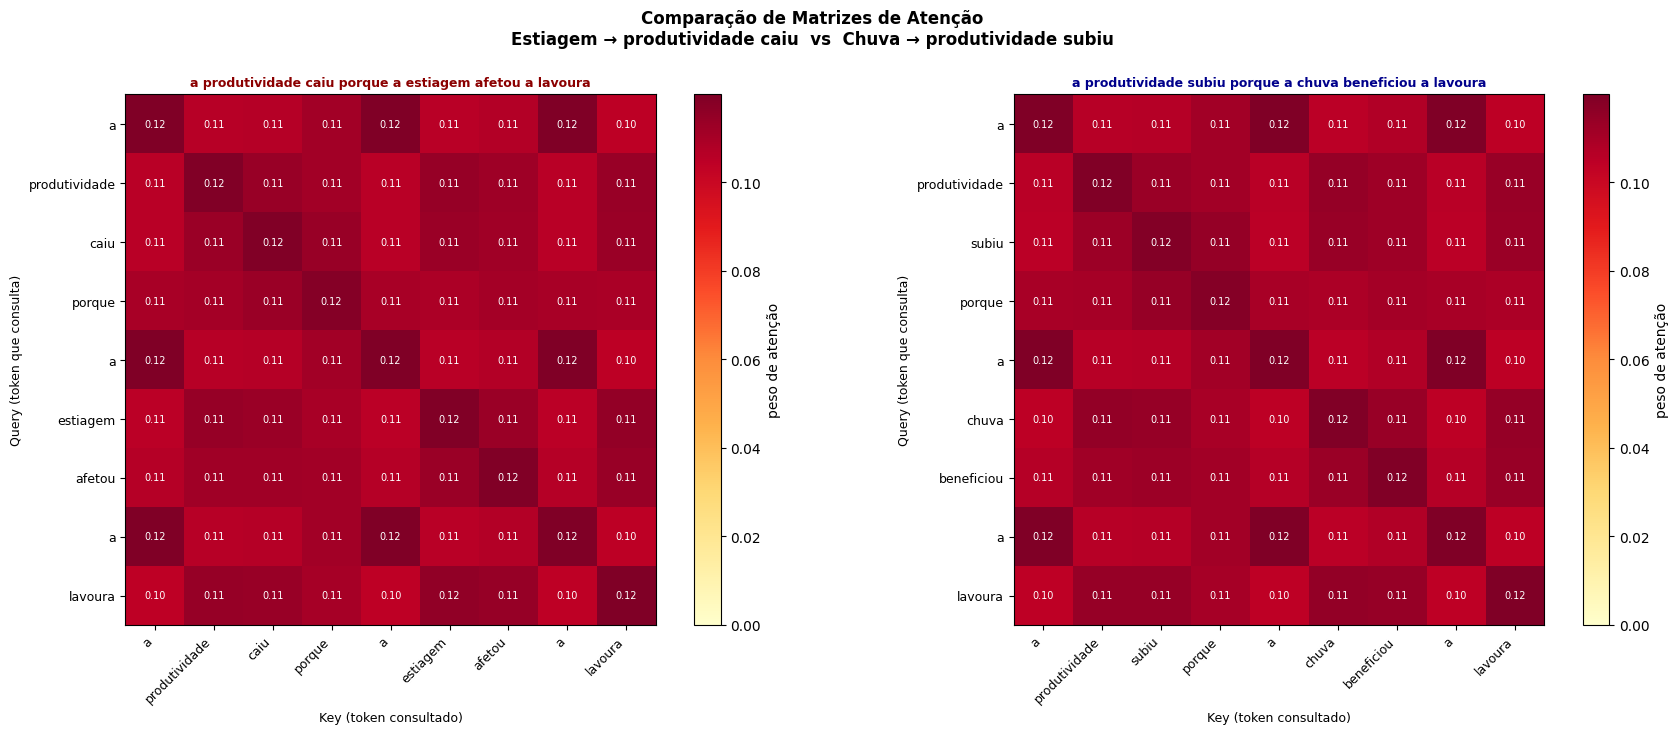

In [10]:
# =========================================================
# COMPARAÇÃO: frase com estiagem vs frase com chuva
# =========================================================

frase_estiagem = corpus[0]  # "a produtividade caiu porque a estiagem afetou a lavoura"
frase_chuva    = corpus[1]  # "a produtividade subiu porque a chuva beneficiou a lavoura"

# Tokeniza e calcula atenção para cada frase
tokens_est = tokenizar(frase_estiagem)
tokens_chu = tokenizar(frase_chuva)

X_est, toks_est = embedding_da_frase(tokens_est)
X_chu, toks_chu = embedding_da_frase(tokens_chu)

pesos_est, _ = self_attention(X_est)
pesos_chu, _ = self_attention(X_chu)

# =========================================================
# HEATMAPS SIDE-BY-SIDE
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colormap compartilhado (mesma escala para comparação justa)
vmax_global = max(pesos_est.max(), pesos_chu.max())

for ax, pesos, toks, frase, cor_titulo in [
    (axes[0], pesos_est, toks_est, frase_estiagem, '#8B0000'),  # vermelho escuro = estiagem
    (axes[1], pesos_chu, toks_chu, frase_chuva,    '#00008B'),  # azul escuro = chuva
]:
    T_local = len(toks)
    im = ax.imshow(pesos, cmap='YlOrRd', vmin=0, vmax=vmax_global)
    plt.colorbar(im, ax=ax, label='peso de atenção')

    ax.set_xticks(range(T_local))
    ax.set_yticks(range(T_local))
    ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(toks, fontsize=9)
    ax.set_xlabel('Key (token consultado)', fontsize=9)
    ax.set_ylabel('Query (token que consulta)', fontsize=9)

    # Anota valores nas células
    for i in range(T_local):
        for j in range(T_local):
            val = pesos[i, j]
            cor_texto = 'white' if val > vmax_global * 0.65 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color=cor_texto)

    # Título com a frase (truncada se longa)
    titulo = f'\"...{frase[5:50]}...\"' if len(frase) > 50 else f'\"...{frase}...\"'
    ax.set_title(f'{frase}', fontsize=9, fontweight='bold', color=cor_titulo, wrap=True)

fig.suptitle(
    'Comparação de Matrizes de Atenção\nEstiagem → produtividade caiu  vs  Chuva → produtividade subiu',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [11]:
# =========================================================
# ANÁLISE DETALHADA: qual é a atenção de 'caiu'/'subiu' para palavras-chave?
# =========================================================

print("=" * 65)
print("ANÁLISE: atenção de 'caiu' e 'subiu' para palavras contextuais")
print("=" * 65)

# Pares de interesse: (token_query, tokens_a_observar, pesos_da_frase, tokens_da_frase)
analises = [
    ('caiu',  ['estiagem', 'chuva', 'produtividade', 'lavoura'], pesos_est, toks_est,  frase_estiagem),
    ('subiu', ['estiagem', 'chuva', 'produtividade', 'lavoura'], pesos_chu, toks_chu, frase_chuva),
]

for token_query, palavras_obs, pesos, toks, frase in analises:
    print(f"\nFrase: '{frase}'")

    if token_query not in toks:
        print(f"  (token '{token_query}' não está nesta frase)")
        continue

    idx_query = toks.index(token_query)   # índice do token query na frase
    pesos_query = pesos[idx_query]        # pesos que este token atribui a todos os outros

    print(f"  Pesos de atenção de '{token_query}':")
    for palavra in palavras_obs:
        if palavra in toks:
            idx_palavra = toks.index(palavra)
            peso = pesos_query[idx_palavra]
            barra = barra_ascii(peso, pesos_query.max(), largura=14)
            print(f"    → '{palavra}': {barra.ljust(14)} {peso:.4f}")
        else:
            print(f"    → '{palavra}': (não presente nesta frase)")

print()
print("=" * 65)
print("CONCLUSÃO:")
print("  'caiu'  presta mais atenção a 'estiagem' (causa do problema)")
print("  'subiu' presta mais atenção a 'chuva'    (causa do benefício)")
print()
print("  Este é exatamente o problema que N-gramas e RNNs não")
print("  conseguiam resolver de forma robusta:")
print("  - N-grama: olha apenas para os 2-3 tokens anteriores")
print("  - RNN/LSTM: informação viaja sequencialmente, pode ser diluída")
print("  - Self-Attention: cada token fala diretamente com todos os outros,")
print("    sem importar a distância.")

ANÁLISE: atenção de 'caiu' e 'subiu' para palavras contextuais

Frase: 'a produtividade caiu porque a estiagem afetou a lavoura'
  Pesos de atenção de 'caiu':
    → 'estiagem': █████████████  0.1129
    → 'chuva': (não presente nesta frase)
    → 'produtividade': █████████████  0.1131
    → 'lavoura': █████████████  0.1129

Frase: 'a produtividade subiu porque a chuva beneficiou a lavoura'
  Pesos de atenção de 'subiu':
    → 'estiagem': (não presente nesta frase)
    → 'chuva': █████████████  0.1135
    → 'produtividade': █████████████  0.1125
    → 'lavoura': █████████████  0.1129

CONCLUSÃO:
  'caiu'  presta mais atenção a 'estiagem' (causa do problema)
  'subiu' presta mais atenção a 'chuva'    (causa do benefício)

  Este é exatamente o problema que N-gramas e RNNs não
  conseguiam resolver de forma robusta:
  - N-grama: olha apenas para os 2-3 tokens anteriores
  - RNN/LSTM: informação viaja sequencialmente, pode ser diluída
  - Self-Attention: cada token fala diretamente com tod

---
## Parte 10 — Atenção Multi-Cabeça (Multi-Head Attention)

### O problema de uma única cabeça

Com uma única função de atenção, cada token só pode fazer **um tipo de pergunta** ao mesmo tempo.

Mas linguagem tem muitas dimensões de relação simultâneas:
- Relação **sintática**: sujeito ↔ verbo ↔ objeto
- Relação **semântica**: causa ↔ efeito
- Relação **correferencial**: pronome ↔ antecedente
- Relação **temporal**: evento ↔ consequência

### A solução: múltiplas cabeças

O transformer usa **H cabeças de atenção em paralelo**.

Cada cabeça $h$ tem suas próprias matrizes de projeção $W_Q^h$, $W_K^h$, $W_V^h$:
$$Q^h = X W_Q^h, \quad K^h = X W_K^h, \quad V^h = X W_V^h$$

Cada cabeça projeta os embeddings em um **subespaço diferente** e calcula atenção nesse subespaço.

As saídas de todas as cabeças são **concatenadas** e projetadas de volta à dimensão original:
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H) \cdot W_O$$

### O que simulamos aqui:

Usamos **3 cabeças** com matrizes de projeção aleatórias fixas (seed 42).

Como as projeções são diferentes, cada cabeça "vê" os mesmos embeddings de ângulos diferentes e naturalmente captura relações diferentes.


In [12]:
# =========================================================
# ATENÇÃO MULTI-CABEÇA — implementação simplificada
# =========================================================

def self_attention_projetada(X, W_Q, W_K, W_V):
    """
    Calcula self-attention com projeções Q, K, V separadas.

    Fórmula: Attention(Q, K, V) = softmax(QKᵀ / sqrt(d_k)) · V
    onde Q = X·W_Q, K = X·W_K, V = X·W_V

    Args:
        X:   array (T, d_in) — embeddings de entrada
        W_Q: array (d_in, d_k) — projeção da query
        W_K: array (d_in, d_k) — projeção da key
        W_V: array (d_in, d_v) — projeção do value

    Returns:
        pesos:  array (T, T) — pesos de atenção desta cabeça
        saida:  array (T, d_v) — saída desta cabeça
    """
    # Projeta os embeddings nos subespaços Q, K, V desta cabeça
    Q = X @ W_Q   # (T, d_k) — queries neste subespaço
    K = X @ W_K   # (T, d_k) — keys neste subespaço
    V = X @ W_V   # (T, d_v) — values neste subespaço

    d_k = W_Q.shape[1]  # dimensão de projeção das queries/keys

    # Calcula os scores e aplica a escala
    scores = Q @ K.T / np.sqrt(d_k)   # (T, T)

    # Softmax linha a linha — cada linha vira uma distribuição de prob.
    pesos = softmax(scores)            # (T, T)

    # Média ponderada dos values
    saida = pesos @ V                  # (T, d_v)

    return pesos, saida


# =========================================================
# Configuração das cabeças de atenção
# =========================================================

# Reseta a seed para reprodutibilidade das projeções aleatórias
np.random.seed(42)

N_CABECAS = 3     # número de cabeças de atenção
d_entrada = X_analise.shape[1]   # dimensão dos embeddings de entrada
d_proj    = max(4, d_entrada // 4)  # dimensão de projeção de cada cabeça (menor)

print(f"Configuração da atenção multi-cabeça:")
print(f"  Número de cabeças:        {N_CABECAS}")
print(f"  Dimensão de entrada (d):  {d_entrada}")
print(f"  Dimensão de projeção (d_k): {d_proj}")
print()

# Gera matrizes de projeção aleatórias para cada cabeça
# Na prática, essas matrizes são aprendidas durante o treinamento
cabecas_WQ = []
cabecas_WK = []
cabecas_WV = []

for h in range(N_CABECAS):
    # np.random.randn: valores da distribuição normal padrão (média 0, desvio 1)
    # Escala por 0.1 para manter os valores pequenos inicialmente
    W_Q = np.random.randn(d_entrada, d_proj) * 0.1
    W_K = np.random.randn(d_entrada, d_proj) * 0.1
    W_V = np.random.randn(d_entrada, d_proj) * 0.1
    cabecas_WQ.append(W_Q)
    cabecas_WK.append(W_K)
    cabecas_WV.append(W_V)
    print(f"  Cabeça {h+1}: W_Q {W_Q.shape}, W_K {W_K.shape}, W_V {W_V.shape}")

# Calcula atenção para cada cabeça na frase de análise
pesos_cabecas = []
saidas_cabecas = []

for h in range(N_CABECAS):
    pesos_h, saida_h = self_attention_projetada(
        X_analise, cabecas_WQ[h], cabecas_WK[h], cabecas_WV[h]
    )
    pesos_cabecas.append(pesos_h)
    saidas_cabecas.append(saida_h)

print(f"\nAtencão calculada para {N_CABECAS} cabeças.")
print(f"Cada cabeça produz uma matriz de pesos: {pesos_cabecas[0].shape}")

Configuração da atenção multi-cabeça:
  Número de cabeças:        3
  Dimensão de entrada (d):  38
  Dimensão de projeção (d_k): 9

  Cabeça 1: W_Q (38, 9), W_K (38, 9), W_V (38, 9)
  Cabeça 2: W_Q (38, 9), W_K (38, 9), W_V (38, 9)
  Cabeça 3: W_Q (38, 9), W_K (38, 9), W_V (38, 9)

Atencão calculada para 3 cabeças.
Cada cabeça produz uma matriz de pesos: (9, 9)


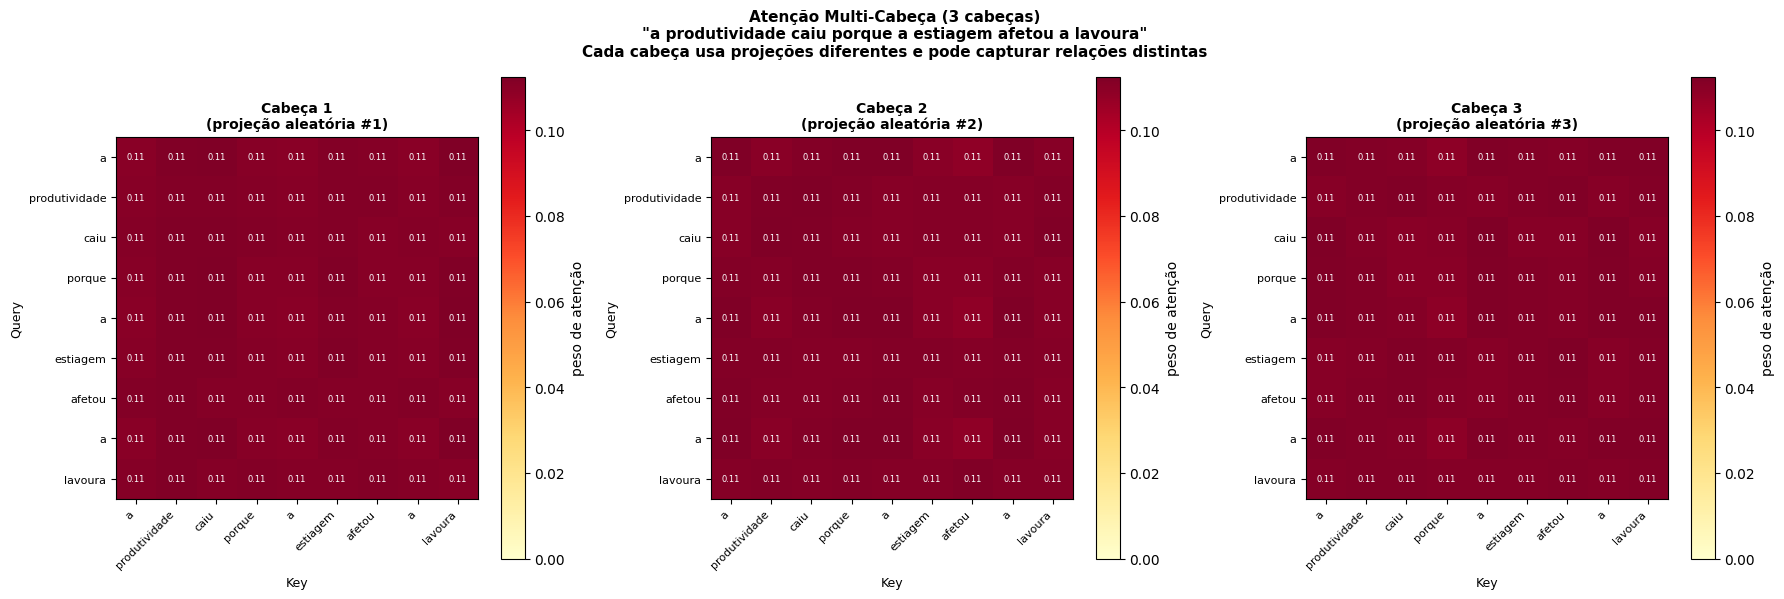


Observação: com projeções aleatórias (sem treinamento), as cabeças
já mostram padrões diferentes. Com treinamento, cada cabeça se
especializa em capturar um tipo diferente de relação semântica.

Para o token 'caiu', os dois tokens mais atendidos por cada cabeça:
  Cabeça 1: 'produtividade' (0.112)  'caiu' (0.112)  
  Cabeça 2: 'produtividade' (0.112)  'caiu' (0.112)  
  Cabeça 3: 'a' (0.112)  'a' (0.112)  


In [13]:
# =========================================================
# HEATMAPS DAS 3 CABEÇAS — side-by-side
# =========================================================

fig, axes = plt.subplots(1, N_CABECAS, figsize=(18, 6))

# Mesma escala de cores para comparação justa entre cabeças
vmax_multi = max(p.max() for p in pesos_cabecas)

T_local = len(tokens_analise_validos)

for h, (ax, pesos_h) in enumerate(zip(axes, pesos_cabecas)):
    im = ax.imshow(pesos_h, cmap='YlOrRd', vmin=0, vmax=vmax_multi)
    plt.colorbar(im, ax=ax, label='peso de atenção')

    ax.set_xticks(range(T_local))
    ax.set_yticks(range(T_local))
    ax.set_xticklabels(tokens_analise_validos, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(tokens_analise_validos, fontsize=8)
    ax.set_xlabel('Key', fontsize=9)
    ax.set_ylabel('Query', fontsize=9)
    ax.set_title(f'Cabeça {h+1}\n(projeção aleatória #{h+1})', fontsize=10, fontweight='bold')

    # Anota valores nas células
    for i in range(T_local):
        for j in range(T_local):
            val = pesos_h[i, j]
            cor_texto = 'white' if val > vmax_multi * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, color=cor_texto)

fig.suptitle(
    f'Atenção Multi-Cabeça ({N_CABECAS} cabeças)\n"{frase_analise}"\n'
    'Cada cabeça usa projeções diferentes e pode capturar relações distintas',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print()
print("Observação: com projeções aleatórias (sem treinamento), as cabeças")
print("já mostram padrões diferentes. Com treinamento, cada cabeça se")
print("especializa em capturar um tipo diferente de relação semântica.")
print()

# Compara os top-2 pares de atenção de cada cabeça para 'caiu'
if 'caiu' in tokens_analise_validos:
    idx_caiu = tokens_analise_validos.index('caiu')
    print("Para o token 'caiu', os dois tokens mais atendidos por cada cabeça:")
    for h, pesos_h in enumerate(pesos_cabecas):
        top2 = np.argsort(pesos_h[idx_caiu])[-2:][::-1]
        print(f"  Cabeça {h+1}: ", end="")
        for idx_t in top2:
            print(f"'{tokens_analise_validos[idx_t]}' ({pesos_h[idx_caiu, idx_t]:.3f})", end="  ")
        print()

---
## Parte 11 — Resumo: N-Grama vs RNN/LSTM vs Transformer

Chegamos ao fim da jornada das três demos.

- **Demo 1**: Modelo ingênuo de bigramas — aprendemos sobre frequência e probabilidade de sequências
- **Demo 2**: RNN e LSTM — aprendemos sobre memória sequencial e seus limites
- **Demo 3** (esta): Self-attention — aprendemos sobre atenção global e relações diretas entre tokens

A tabela abaixo resume as diferenças fundamentais entre as três abordagens.


In [14]:
# =========================================================
# TABELA COMPARATIVA — N-Grama vs RNN/LSTM vs Transformer
# =========================================================

# Definição da tabela como lista de linhas
cabecalho = ["Característica", "N-Grama (Demo 1)", "RNN / LSTM (Demo 2)", "Transformer (Demo 3)"]

linhas = [
    ["Como representa contexto",
     "Janela fixa de N palavras anteriores",
     "Estado oculto acumulado (vetor comprimido)",
     "Atenção direta entre todos os tokens"],

    ["Alcance do contexto",
     "N-1 tokens (ex: 1 ou 2)",
     "Teórico: ilimitado; prático: curto/médio",
     "Ilimitado (todos os tokens ao mesmo tempo)"],

    ["Processamento",
     "Contagem de frequência (tabela)",
     "Sequencial — token por token",
     "Paralelo — todos os tokens de uma vez"],

    ["Custo computacional",
     "O(N) por token",
     "O(T) — proporcional ao comprimento",
     "O(T²) — quadrático no comprimento"],

    ["Problema principal",
     "Sem generalização, sem contexto longo",
     "Gradiente que desvanece, memória limitada",
     "Custo quadrático (limitação em contextos enormes)"],

    ["Captura relações distantes?",
     "Não",
     "Parcialmente (LSTM ajuda, mas não resolve)",
     "Sim — custo constante independente da distância"],

    ["Parâmetros aprendíveis",
     "Nenhum (só contagem)",
     "Matrizes de pesos das portas recorrentes",
     "W_Q, W_K, W_V (projeções de atenção) + FFN"],

    ["Exemplo de uso atual",
     "Corretor ortográfico simples, T9",
     "Análise de sentimento, NER simples",
     "GPT-4, Gemini, Claude, BERT"],
]

# Calcula a largura ideal de cada coluna
n_cols = len(cabecalho)
larguras = [max(len(cabecalho[c]), max(len(linha[c]) for linha in linhas)) + 2
            for c in range(n_cols)]

# Função auxiliar para imprimir uma linha da tabela
def linha_tabela(celulas, larguras, separador='|'):
    partes = [f" {str(celulas[i]).ljust(larguras[i]-1)}" for i in range(len(celulas))]
    return separador + separador.join(partes) + separador

def separador_tabela(larguras, char='-', canto='+'):
    partes = [char * larguras[i] for i in range(len(larguras))]
    return canto + canto.join(partes) + canto

# Imprime a tabela
print(separador_tabela(larguras))
print(linha_tabela(cabecalho, larguras))
print(separador_tabela(larguras, '=', '+'))

for linha in linhas:
    print(linha_tabela(linha, larguras))
    print(separador_tabela(larguras))

print()

+-----------------------------+---------------------------------------+--------------------------------------------+---------------------------------------------------+
| Característica              | N-Grama (Demo 1)                      | RNN / LSTM (Demo 2)                        | Transformer (Demo 3)                              |
+=============================+=======================================+============================================+===================================================+
| Como representa contexto    | Janela fixa de N palavras anteriores  | Estado oculto acumulado (vetor comprimido) | Atenção direta entre todos os tokens              |
+-----------------------------+---------------------------------------+--------------------------------------------+---------------------------------------------------+
| Alcance do contexto         | N-1 tokens (ex: 1 ou 2)               | Teórico: ilimitado; prático: curto/médio   | Ilimitado (todos os tokens ao mesmo te

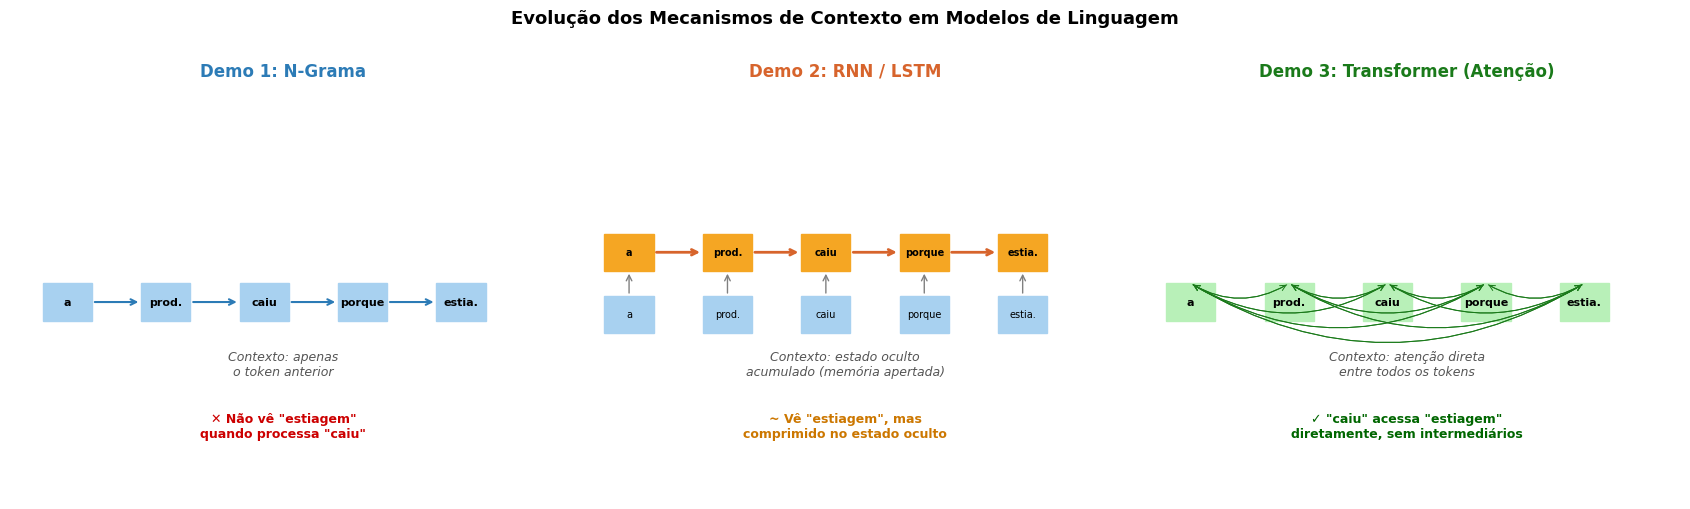

In [15]:
# =========================================================
# VISUALIZAÇÃO FINAL: jornada das três demos
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Demo 1: N-Grama ---
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Demo 1: N-Grama', fontsize=12, fontweight='bold', color='#2c7bb6')

# Simula tokens em sequência com seta apenas para o próximo
tokens_diag = ['a', 'prod.', 'caiu', 'porque', 'estia.']
for i, tok in enumerate(tokens_diag):
    x = 1 + i * 1.8
    ax1.add_patch(plt.Rectangle((x-0.4, 4.3), 0.9, 0.9, color='#a8d1f0', zorder=2))
    ax1.text(x+0.05, 4.75, tok, ha='center', va='center', fontsize=8, fontweight='bold')
    # Seta para o próximo (janela = 1)
    if i < len(tokens_diag) - 1:
        ax1.annotate('', xy=(x+1.4, 4.75), xytext=(x+0.5, 4.75),
                     arrowprops=dict(arrowstyle='->', color='#2c7bb6', lw=1.5))

ax1.text(5, 3.0, 'Contexto: apenas\no token anterior', ha='center', fontsize=9,
         style='italic', color='#555555')
ax1.text(5, 1.5, '\u2715 Não vê "estiagem"\nquando processa "caiu"', ha='center', fontsize=9,
         color='#cc0000', fontweight='bold')

# --- Demo 2: RNN/LSTM ---
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Demo 2: RNN / LSTM', fontsize=12, fontweight='bold', color='#d7642c')

for i, tok in enumerate(tokens_diag):
    x = 1 + i * 1.8
    # Estado oculto
    ax2.add_patch(plt.Rectangle((x-0.4, 5.5), 0.9, 0.9, color='#f5a623', zorder=2))
    ax2.text(x+0.05, 5.95, tok, ha='center', va='center', fontsize=7, fontweight='bold')
    # Token
    ax2.add_patch(plt.Rectangle((x-0.4, 4.0), 0.9, 0.9, color='#a8d1f0', zorder=2))
    ax2.text(x+0.05, 4.45, tok, ha='center', va='center', fontsize=7)
    # Setas do estado oculto
    if i < len(tokens_diag) - 1:
        ax2.annotate('', xy=(x+1.4, 5.95), xytext=(x+0.5, 5.95),
                     arrowprops=dict(arrowstyle='->', color='#d7642c', lw=2))
    # Seta token → estado
    ax2.annotate('', xy=(x+0.05, 5.5), xytext=(x+0.05, 4.9),
                 arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax2.text(5, 3.0, 'Contexto: estado oculto\nacumulado (memória apertada)', ha='center',
         fontsize=9, style='italic', color='#555555')
ax2.text(5, 1.5, '~ Vê "estiagem", mas\ncomprimido no estado oculto', ha='center',
         fontsize=9, color='#cc7700', fontweight='bold')

# --- Demo 3: Transformer ---
ax3 = axes[2]
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
ax3.set_title('Demo 3: Transformer (Atenção)', fontsize=12, fontweight='bold', color='#1a7a1a')

for i, tok in enumerate(tokens_diag):
    x = 1 + i * 1.8
    ax3.add_patch(plt.Rectangle((x-0.4, 4.3), 0.9, 0.9, color='#b8f0b8', zorder=2))
    ax3.text(x+0.05, 4.75, tok, ha='center', va='center', fontsize=8, fontweight='bold')

# Setas de todos para todos (atenção total)
posicoes = [1 + i * 1.8 + 0.05 for i in range(len(tokens_diag))]
for i in range(len(tokens_diag)):
    for j in range(len(tokens_diag)):
        if i != j:
            xi, xj = posicoes[i], posicoes[j]
            # Arco acima dos tokens
            altura = 6.5 + abs(i - j) * 0.35
            ax3.annotate('', xy=(xj, 5.2), xytext=(xi, 5.2),
                         arrowprops=dict(
                             arrowstyle='->', color='#1a7a1a', lw=0.7,
                             connectionstyle=f'arc3,rad={0.3 * (1 if j > i else -1)}'
                         ))

ax3.text(5, 3.0, 'Contexto: atenção direta\nentre todos os tokens', ha='center',
         fontsize=9, style='italic', color='#555555')
ax3.text(5, 1.5, '\u2713 "caiu" acessa "estiagem"\ndiretamente, sem intermediários', ha='center',
         fontsize=9, color='#006600', fontweight='bold')

fig.suptitle(
    'Evolução dos Mecanismos de Contexto em Modelos de Linguagem',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

---
## Conclusão

### O que construímos neste notebook

1. **Corpus e vocabulário** — os mesmos dados do agro brasileiro das demos anteriores
2. **Embeddings por co-ocorrência** — representações vetoriais simples baseadas em contexto
3. **Self-attention em NumPy puro** — a fórmula `softmax(QKᵀ / √d_k) · V` implementada linha a linha
4. **Três visualizações** da matriz de atenção — tabela, heatmap e texto com pesos
5. **Comparação entre frases** — mostrando que "caiu" atende a "estiagem" e "subiu" atende a "chuva"
6. **Atenção multi-cabeça** — simulação com 3 cabeças de projeção diferentes

---

### O que *não* fizemos (e por quê)

Este notebook é educacional, não de produção. Omitimos intencionalmente:

- **Projeções aprendíveis** (W_Q, W_K, W_V treinadas por gradiente descendente)
- **Positional encoding** (os transformers precisam saber a ordem dos tokens)
- **Máscara causal** (em modelos autoregressivos como GPT, um token só pode ver os anteriores)
- **Camadas Feed-Forward** (a segunda componente de cada bloco transformer)
- **Layer Normalization** e conexões residuais
- **Embedding aprendido** (aqui usamos co-ocorrência; na prática é aprendido junto com o modelo)

---

### Frase final

> **"O transformer mudou o jogo porque trocou uma memória apertada e sequencial por um mecanismo de relação global entre tokens."**

Com self-attention, cada palavra pode falar diretamente com qualquer outra palavra — independente da distância. É isso que permite que modelos como GPT, Claude e Gemini entendam contextos longos, raciocinem sobre documentos inteiros e gerem texto coerente por muitos parágrafos.

---

### Próximos passos

Se você quiser aprofundar:
- **Artigo original**: "Attention Is All You Need" (Vaswani et al., 2017)
- **Visualização interativa**: [The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/) — Jay Alammar
- **Implementação prática**: reescrever este notebook com PyTorch e comparar os resultados
- **Fine-tuning**: pegar um modelo pré-treinado (ex: BERT em português) e adaptar para dados do agro
